# 05 — XGBoost
Walk-forward XGBoost on weekly silver log-returns with lagged features.
Same train/val/test split and evaluation metrics as the ARIMA and LSTM notebooks.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

## 1. Load features

In [28]:
# Weekly feature frame (built once by 02_features.ipynb §8 — single source of truth).
weekly = pd.read_csv('../../data/processed/features_weekly.csv', index_col=0, parse_dates=True)

TARGET       = 'silver_return'
EXOG_RETURNS = ['gold_return', 'usd_return', 'copper_return', 'sp500_return',
                'vix_return', 'oil_return']
EXOG_LEVELS  = ['gs_ratio_z']   # level feature — separate group for ablation (see §8)
EXOG         = EXOG_RETURNS + EXOG_LEVELS

# Base weekly matrix: target + cross-asset returns + gs_ratio_z. The frame is un-lagged
# (build_features applies the 1-week lag); the W-FRI aggregation lives in 02_features.
base_cols = [TARGET] + EXOG_RETURNS + EXOG_LEVELS
all_w   = weekly[base_cols].dropna().copy()
n_train = int((weekly.loc[all_w.index, 'split'] != 'test').sum())

print(f'Weekly obs — train+val: {n_train}, test: {len(all_w) - n_train}')
print(f'Features available: {[c for c in EXOG if c in all_w.columns]}')

Weekly obs — train+val: 417, test: 174
Features available: ['gold_return', 'usd_return', 'copper_return', 'sp500_return', 'vix_return', 'oil_return', 'gs_ratio_z']


## 2. Build all feature groups

Build every feature set up front — the EXOG base (silver AR lags + 6 cross-asset return lags) and
all ablation groups (GS / NonLin / Tech / Macro / FRED_daily / COT / sentiment / BestLag) — so the
variant ladder (§4) is the *only* place models are fit. Base groups get the 1-week lag here; TECH /
MACRO are already lagged in the frame; BestLag columns are pre-lagged (used as-is). A missing column
errors loudly (the frame always carries every group).

In [29]:
import json
GROUPS = json.load(open('../../data/processed/feature_groups.json'))

def build_features(df):
    '''EXOG base: 6 lagged cross-asset returns + silver AR lags 1-3 (gs_ratio_z is its own +GS rung).'''
    X = pd.DataFrame(index=df.index)
    for col in [c for c in EXOG_RETURNS if c in df.columns]:
        X[f'{col}_lag1'] = df[col].shift(1)
    for lag in [1, 2, 3]:
        X[f'silver_lag{lag}'] = df[TARGET].shift(lag)
    return X

features_all = build_features(all_w)

# Test target / index (used by the ladder + everything downstream).
y_test     = all_w[TARGET].iloc[n_train:].values
test_index = all_w.index[n_train:]

# -- Ablation groups, each as {feature_name: weekly_series} -----------------------
def lag1(cols):
    return {f'{c}_lag1': weekly[c].shift(1) for c in cols}

GS_COLS       = lag1(GROUPS['GS'])
FRED_COLS     = lag1(GROUPS['FRED_DAILY'])
COT_COLS      = lag1(GROUPS['COT'])
SENT_COLS     = lag1(GROUPS['SENT'])
REDDIT_COLS   = {'reddit_sentiment_lag1': SENT_COLS['reddit_sentiment_lag1']}
NEWS_COLS     = {'news_sentiment_lag1':   SENT_COLS['news_sentiment_lag1']}
MACRO_COLS    = {c: weekly[c] for c in GROUPS['MACRO']}   # leak-corrected, already lagged
MACROCOT_COLS = {**FRED_COLS, **COT_COLS}
tech_dict     = lag1(GROUPS['TECH'])                      # directional -- lagged 1w here, like GS/FRED/COT
BESTLAG_ALL_COLS   = {c: weekly[c] for c in GROUPS['BESTLAG_ALL']}    # pre-lagged (used as-is)
BESTLAG_SIG90_COLS = {c: weekly[c] for c in GROUPS['BESTLAG_SIG90']}
BESTLAG_SIG_COLS   = {c: weekly[c] for c in GROUPS['BESTLAG_SIG']}

SILVER_LAGS = [c for c in features_all.columns if c.startswith('silver_lag')]
ALL_BASE    = list(features_all.columns)                  # silver lags + cross-asset return lags
NONLIN_COLS = {f'{c}_sq': features_all[c] ** 2 for c in features_all.columns}   # squared lags
# Kitchen-sink extras (the EXOG+ALL rung + the feature-importance model).
ALL_EXTRA   = {**GS_COLS, **NONLIN_COLS, **tech_dict, **MACROCOT_COLS, **SENT_COLS}

print(f'EXOG base ({len(ALL_BASE)}):', ALL_BASE)
print(f'EXOG+ALL feature count: {len(ALL_BASE) + len(ALL_EXTRA)}')

EXOG base (9): ['gold_return_lag1', 'usd_return_lag1', 'copper_return_lag1', 'sp500_return_lag1', 'vix_return_lag1', 'oil_return_lag1', 'silver_lag1', 'silver_lag2', 'silver_lag3']
EXOG+ALL feature count: 36


## 3. Tuning + walk-forward helpers

`tune()` grid-searches the XGBoost hyperparameters via `TimeSeriesSplit(5)` CV on **train+val** (no
test peek). `walk_forward()` does 1-step-ahead forecasting, refitting every 4 weeks, expanding
(default) or rolling-100w. Each variant is tuned on its **own** feature set in the ladder (§4) — so a
difference between rungs is the features given each its best hyperparameters, not a shared HP handicap.

In [30]:
from itertools import product
param_grid = {
    'n_estimators':     [100, 200],
    'max_depth':        [2, 3, 4],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
}
tscv   = TimeSeriesSplit(n_splits=5)
keys   = list(param_grid.keys())
combos = list(product(*param_grid.values()))
print(f'Grid: {len(combos)} combinations per variant')

def tune(X_tr_s, y_tr_s):
    '''Grid-search XGB hyperparameters by TimeSeriesSplit CV-RMSE on train+val.'''
    mask_s = ~np.isnan(X_tr_s).any(axis=1)
    X_tr_s, y_tr_s = X_tr_s[mask_s], y_tr_s[mask_s]
    best_rmse_s, best_params_s = np.inf, {}
    for combo in combos:
        params = dict(zip(keys, combo))
        fold_rmses = []
        for fold_tr, fold_val in tscv.split(X_tr_s):
            m = XGBRegressor(random_state=42, verbosity=0, **params)
            m.fit(X_tr_s[fold_tr], y_tr_s[fold_tr])
            fold_rmses.append(np.sqrt(mean_squared_error(y_tr_s[fold_val], m.predict(X_tr_s[fold_val]))))
        rmse = np.mean(fold_rmses)
        if rmse < best_rmse_s:
            best_rmse_s, best_params_s = rmse, params
    return best_params_s

def walk_forward(all_w, features_all, n_train, feature_cols,
                 retrain_every=4, window=None, **xgb_kwargs):
    '''window=None -> expanding; window=N -> rolling (last N weeks). Refit every retrain_every.'''
    y_all = all_w[TARGET].values
    X_all = features_all[feature_cols].values
    preds = np.full(len(all_w) - n_train, np.nan)
    model = None
    for i, t in enumerate(range(n_train, len(all_w))):
        start = max(0, t - window) if window else 0
        X_tr, y_tr = X_all[start:t], y_all[start:t]
        X_te = X_all[t:t+1]
        mask = ~np.isnan(X_tr).any(axis=1)
        if mask.sum() < 10 or np.isnan(X_te).any():
            continue
        if model is None or i % retrain_every == 0:
            model = XGBRegressor(random_state=42, verbosity=0, **xgb_kwargs)
            model.fit(X_tr[mask], y_tr[mask])
        preds[i] = model.predict(X_te)[0]
    return preds

Grid: 72 combinations per variant


## 4. Variant ladder

Every variant — **EXOG is just rung 0** — is tuned on its own feature set and walk-forwarded in both
windows (expanding + rolling-100w), mirroring the `01_arima` ladder. `Tech` and the BestLag rungs use
the silver AR base only (no cross-assets); everything else builds on EXOG. Each variant's tuned params
are stashed in `variant_params` (the `EXOG+ALL` set feeds the feature-importance plot in §6).

In [31]:
import sys, os
sys.path.insert(0, os.path.abspath('../../src'))
from eval_utils import evaluate, period_metrics, diebold_mariano, PERIODS

all_candidates = {}
variant_params = {}

def run_variant(label, base_cols, extra_cols=None):
    '''Tune on this variant own features, then walk-forward both windows.'''
    print(f"--- {label} ---", flush=True)
    feats = features_all[list(base_cols)].copy()
    for col_name, series in (extra_cols or {}).items():
        feats[col_name] = series.reindex(feats.index).ffill()
    fcols = feats.columns.tolist()
    params = tune(feats.iloc[:n_train][fcols].values, all_w[TARGET].iloc[:n_train].values)
    variant_params[label] = params
    p_exp = walk_forward(all_w, feats, n_train, fcols,             **params)
    p_rol = walk_forward(all_w, feats, n_train, fcols, window=100, **params)
    evaluate(f"{label} expanding",      y_test, p_exp)
    evaluate(f"{label} rolling (100w)", y_test, p_rol)
    all_candidates[f"{label} expanding"]      = p_exp
    all_candidates[f"{label} rolling (100w)"] = p_rol

run_variant("EXOG",                  ALL_BASE)                 # rung 0 -- baseline
run_variant("Tech",                  SILVER_LAGS, tech_dict)
run_variant("EXOG+GS",               ALL_BASE, GS_COLS)
run_variant("EXOG+NonLin",           ALL_BASE, NONLIN_COLS)
run_variant("EXOG+Tech",             ALL_BASE, tech_dict)
run_variant("EXOG+Macro",            ALL_BASE, MACRO_COLS)
run_variant("EXOG+FRED_daily",       ALL_BASE, FRED_COLS)
run_variant("EXOG+COT",              ALL_BASE, COT_COLS)
run_variant("EXOG+FRED_daily+COT",   ALL_BASE, MACROCOT_COLS)
run_variant("EXOG+Reddit+News",      ALL_BASE, SENT_COLS)
run_variant("EXOG+Reddit",           ALL_BASE, REDDIT_COLS)
run_variant("EXOG+News",             ALL_BASE, NEWS_COLS)
run_variant("EXOG+GS+Sentiment",     ALL_BASE, {**GS_COLS, **SENT_COLS})
run_variant("EXOG+NonLin+Sentiment", ALL_BASE, {**NONLIN_COLS, **SENT_COLS})
run_variant("EXOG+Tech+Sentiment",   ALL_BASE, {**tech_dict, **SENT_COLS})
run_variant("EXOG+ALL",              ALL_BASE, ALL_EXTRA)
run_variant("BestLag-All",   SILVER_LAGS, BESTLAG_ALL_COLS)
run_variant("BestLag-Sig90", SILVER_LAGS, BESTLAG_SIG90_COLS)
run_variant("BestLag-Sig",   SILVER_LAGS, BESTLAG_SIG_COLS)

--- EXOG ---
EXOG expanding                                 RMSE=0.05194  MAE=0.03739  DA=0.529  WDA=0.580
EXOG rolling (100w)                            RMSE=0.05319  MAE=0.03804  DA=0.506  WDA=0.524
--- Tech ---
Tech expanding                                 RMSE=0.05202  MAE=0.03727  DA=0.529  WDA=0.542
Tech rolling (100w)                            RMSE=0.05282  MAE=0.03739  DA=0.540  WDA=0.524
--- EXOG+GS ---
EXOG+GS expanding                              RMSE=0.05187  MAE=0.03691  DA=0.540  WDA=0.557
EXOG+GS rolling (100w)                         RMSE=0.05288  MAE=0.03716  DA=0.546  WDA=0.550
--- EXOG+NonLin ---
EXOG+NonLin expanding                          RMSE=0.05160  MAE=0.03734  DA=0.546  WDA=0.601
EXOG+NonLin rolling (100w)                     RMSE=0.05351  MAE=0.03828  DA=0.489  WDA=0.530
--- EXOG+Tech ---
EXOG+Tech expanding                            RMSE=0.05236  MAE=0.03741  DA=0.546  WDA=0.560
EXOG+Tech rolling (100w)                       RMSE=0.05308  MAE=0.03755  

## 5. Evaluate

One table — RMSE / MAE / DA / WDA for the benchmarks and every variant (both windows). **Drift
(prevailing mean = the random-walk-with-drift floor)** is the bar the DM tests read against; `Naive`
is a weak reference. (Weak form proper is isolated in ARIMA — the trees bundle own-history + public info.)

**Metrics** — RMSE / MAE (point-forecast error, magnitude), OOS R² (effect size vs Drift, shown as `r2_os` in the table below), DA / WDA (directional). Formulas, caveats, and load-bearing status: `01_arima` §5 or [`tests.md`](tests.md).

In [32]:
from eval_utils import oos_r2

# Naive: 1-step shift -> evaluated on y_test[1:] separately (different effective length).
naive_m = evaluate('Naive (t-1 week)', y_test[1:], naive_pred[1:])
if naive_m: naive_m['r2_os'] = float('nan')   # different y length -- OOS R^2 not comparable

# Drift + all variants at full test length; r2_os computed inline (0 for Drift itself).
eval_preds = {'Drift (prevailing mean)': drift_pred, **all_candidates}
main_evals = []
for name, pred in eval_preds.items():
    m = evaluate(name, y_test, pred)
    if m:
        m['r2_os'] = oos_r2(y_test, pred, drift_pred) * 100   # >0 beats the random walk OOS
        main_evals.append(m)

metrics_df = pd.DataFrame(([naive_m] if naive_m else []) + main_evals)
metrics_df = metrics_df[['model', 'rmse', 'mae', 'r2_os', 'dir_acc', 'wda']]   # r2_os next to error metrics
metrics_df.to_csv('../../data/processed/metrics_xgboost.csv', index=False)

# Drift WDA by period (Drift's sign is always positive = the always-up line; the WDA to beat).
_yt = pd.Series(y_test, index=test_index)
print('\nDrift WDA by period (directional benchmark to beat):')
for _lbl, (_a, _b) in PERIODS.items():
    _s = _yt.loc[_a:_b]
    if len(_s):
        _au = np.sum(np.abs(_s.values) * (_s.values > 0)) / np.sum(np.abs(_s.values))
        print(f'  {_lbl:20s} WDA={_au:.3f}  (n={len(_s)})')

metrics_df

Naive (t-1 week)                               RMSE=0.07594  MAE=0.05397  DA=0.491  WDA=0.490
Drift (prevailing mean)                        RMSE=0.05190  MAE=0.03714  DA=0.557  WDA=0.588
EXOG expanding                                 RMSE=0.05194  MAE=0.03739  DA=0.529  WDA=0.580
EXOG rolling (100w)                            RMSE=0.05319  MAE=0.03804  DA=0.506  WDA=0.524
Tech expanding                                 RMSE=0.05202  MAE=0.03727  DA=0.529  WDA=0.542
Tech rolling (100w)                            RMSE=0.05282  MAE=0.03739  DA=0.540  WDA=0.524
EXOG+GS expanding                              RMSE=0.05187  MAE=0.03691  DA=0.540  WDA=0.557
EXOG+GS rolling (100w)                         RMSE=0.05288  MAE=0.03716  DA=0.546  WDA=0.550
EXOG+NonLin expanding                          RMSE=0.05160  MAE=0.03734  DA=0.546  WDA=0.601
EXOG+NonLin rolling (100w)                     RMSE=0.05351  MAE=0.03828  DA=0.489  WDA=0.530
EXOG+Tech expanding                            RMSE=0.05236 

,model,rmse,mae,r2_os,dir_acc,wda
0,Naive (t-1 week),0.075941,0.053966,NaN,0.491329,0.489862
1,Drift (prevailing mean),0.051902,0.037135,0.000000,0.557471,0.587779
2,EXOG expanding,0.051937,0.037392,-0.134341,0.528736,0.580204
3,EXOG rolling (100w),0.053189,0.038043,-5.019678,0.505747,0.523985
4,Tech expanding,0.052023,0.037267,-0.464897,0.528736,0.542360
5,Tech rolling (100w),0.052825,0.037389,-3.585420,0.540230,0.524121
6,EXOG+GS expanding,0.051867,0.036912,0.134648,0.540230,0.556790
7,EXOG+GS rolling (100w),0.052876,0.037163,-3.786083,0.545977,0.550399
8,EXOG+NonLin expanding,0.051599,0.037335,1.165541,0.545977,0.601445
9,EXOG+NonLin rolling (100w),0.053509,0.038280,-6.287648,0.488506,0.529596


## 6. Feature importance (EXOG+ALL model)

Gain importance from a single XGBoost fit on the **full EXOG+ALL feature set** (train+val) with that
rung's tuned hyperparameters — so every public-info feature is ranked against the cross-asset returns,
not just the EXOG base. (A single in-sample fit, for interpretation; the forecasts come from §4.)

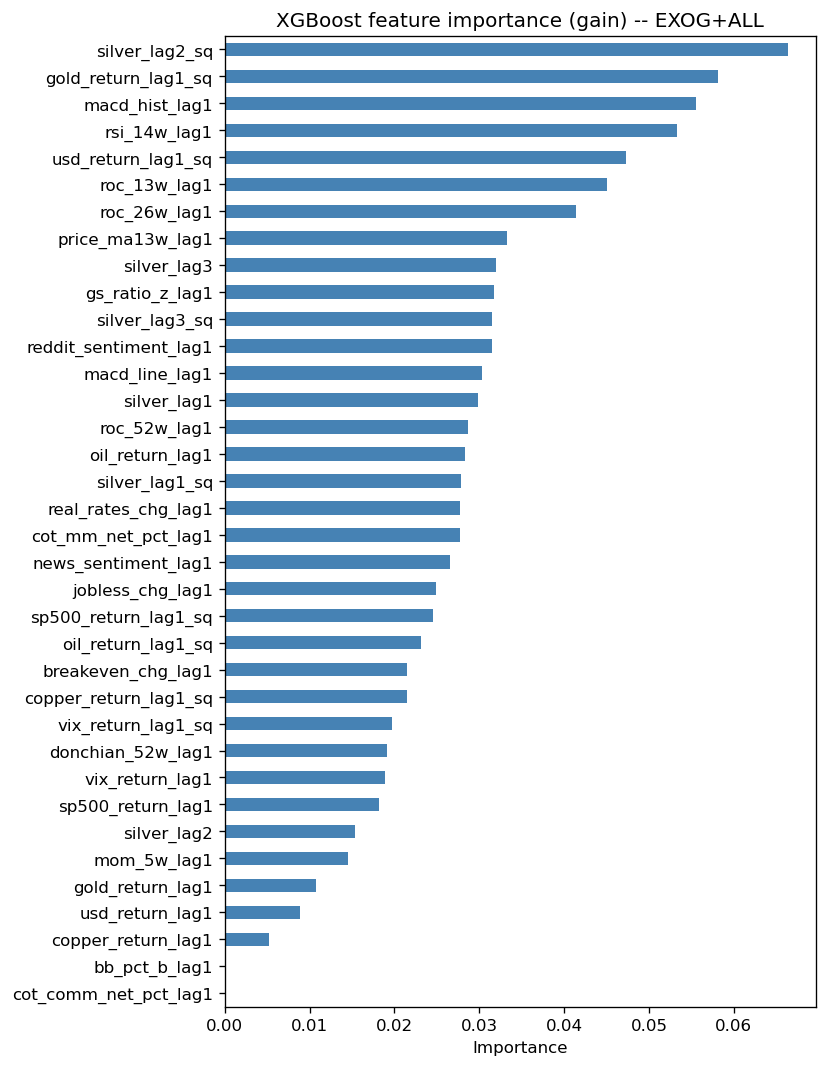

silver_lag2_sq           0.066357
gold_return_lag1_sq      0.058081
macd_hist_lag1           0.055591
rsi_14w_lag1             0.053313
usd_return_lag1_sq       0.047243
roc_13w_lag1             0.045062
roc_26w_lag1             0.041376
price_ma13w_lag1         0.033307
silver_lag3              0.031913
gs_ratio_z_lag1          0.031726
silver_lag3_sq           0.031535
reddit_sentiment_lag1    0.031503
macd_line_lag1           0.030265
silver_lag1              0.029879
roc_52w_lag1             0.028711
oil_return_lag1          0.028294
silver_lag1_sq           0.027881
real_rates_chg_lag1      0.027733
cot_mm_net_pct_lag1      0.027712
news_sentiment_lag1      0.026501
dtype: float32


In [33]:
# Fit one XGBoost on the full EXOG+ALL feature set (train+val) with its tuned params -> gain importances.
imp_feats = features_all[ALL_BASE].copy()
for col_name, series in ALL_EXTRA.items():
    imp_feats[col_name] = series.reindex(imp_feats.index).ffill()
imp_cols = imp_feats.columns.tolist()

X_imp = imp_feats.iloc[:n_train][imp_cols].values
y_imp = all_w[TARGET].iloc[:n_train].values
mask  = ~np.isnan(X_imp).any(axis=1)

imp_model = XGBRegressor(random_state=42, verbosity=0, **variant_params['EXOG+ALL'])
imp_model.fit(X_imp[mask], y_imp[mask])
importances = pd.Series(imp_model.feature_importances_, index=imp_cols).sort_values()

fig, ax = plt.subplots(figsize=(7, max(4, 0.25 * len(imp_cols))))
importances.plot.barh(ax=ax, color='steelblue')
ax.set_title('XGBoost feature importance (gain) -- EXOG+ALL')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()
print(importances.sort_values(ascending=False).head(20))

## 7. Sub-period robustness + best-variant selection

Pick the best variant by **RMSE** (primary, magnitude — §3a) and **WDA** (secondary, directional),
and break each down by calendar year to check the result isn't driven by one regime.

**Saved for cross-model use:** WDA-best keeps the legacy filenames (`period_xgboost_weekly.csv`,
`preds_xgboost_best_weekly.csv`) so `evaluation.ipynb` is untouched; RMSE-best saved alongside
(`period_xgboost_rmse_weekly.csv`, `preds_xgboost_bestrmse_weekly.csv`).

In [34]:
def _best_by_wda(candidates, actual):
    return max(candidates, key=lambda k:
        np.nansum(np.abs(actual) * (np.sign(actual) == np.sign(candidates[k]))) /
        np.nansum(np.abs(actual)))

def _best_by_rmse(candidates, actual):
    return min(candidates, key=lambda k:
        np.sqrt(np.nanmean((actual - candidates[k]) ** 2)))

def _period_r2(pred):
    # OOS R^2 vs Drift, per calendar sub-period (Campbell-Thompson) -- effect-size companion to
    # the per-period error metrics. Drift is the random-walk-with-drift benchmark.
    drift_s, pred_s = pd.Series(drift_pred, index=test_index), pd.Series(pred, index=test_index)
    r2 = {}
    for _lbl, (_a, _b) in PERIODS.items():
        _y  = pd.Series(y_test, index=test_index).loc[_a:_b].values
        _p  = pred_s.loc[_a:_b].values
        _d  = drift_s.loc[_a:_b].values
        if len(_y):
            r2[_lbl] = oos_r2(_y, _p, _d) * 100
    return r2

def _show_period(pred, csv=None):
    res = period_metrics(y_test, pred, test_index, PERIODS)   # RMSE / MAE / DA / WDA per period
    r2  = _period_r2(pred)
    res['R2_OS'] = [r2.get(lbl, float('nan')) for lbl in res.index]
    display(res[['n', 'RMSE', 'MAE', 'R2_OS', 'DA', 'WDA']].style
            .format({'n': '{:.0f}', 'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R2_OS': '{:+.2f}',
                     'DA': '{:.3f}', 'WDA': '{:.3f}'})
            .background_gradient(cmap='RdYlGn', subset=['DA', 'WDA'], vmin=0.4, vmax=0.7))
    if csv:
        res[['n', 'DA', 'WDA']].to_csv(csv)   # legacy schema -- evaluation.ipynb reads these

def _save_preds(pred, csv):
    pd.DataFrame({'actual': y_test, 'predicted': pred}, index=test_index) \
      .rename_axis('Date').to_csv(csv)

best_name      = _best_by_wda(all_candidates, y_test)    # WDA-best (legacy cross-model pick)
best_name_rmse = _best_by_rmse(all_candidates, y_test)
best_pred      = all_candidates[best_name]
best_pred_rmse = all_candidates[best_name_rmse]
print('Best variant -- WDA:', best_name, '|  RMSE:', best_name_rmse)

# Drift by period -- the benchmark to clear per regime.
print('\nDrift (prevailing mean) by period -- the floor:')
_show_period(drift_pred)

print('\nWDA-best by period:')
_show_period(best_pred,      '../../data/processed/period_xgboost_weekly.csv')
print('RMSE-best by period:')
_show_period(best_pred_rmse, '../../data/processed/period_xgboost_rmse_weekly.csv')

_save_preds(best_pred,      '../../data/processed/preds_xgboost_best_weekly.csv')
_save_preds(best_pred_rmse, '../../data/processed/preds_xgboost_bestrmse_weekly.csv')
print('\nSaved: period + preds (WDA-best legacy names, RMSE-best alongside).')

Best variant -- WDA: EXOG+Reddit expanding |  RMSE: EXOG+ALL expanding

Drift (prevailing mean) by period -- the floor:


,n,RMSE,MAE,R2_OS,DA,WDA
Period,,,,,,
2023 (choppy),52,0.0400,0.0318,+0.00,0.481,0.492
2024 (bull start),52,0.0380,0.0299,+0.00,0.500,0.570
2025 (bull run),52,0.0498,0.0352,+0.00,0.692,0.757
2026 (YTD),18,0.1003,0.0791,+0.00,0.556,0.498
── Full test ──,174,0.0519,0.0371,+0.00,0.557,0.588



WDA-best by period:


,n,RMSE,MAE,R2_OS,DA,WDA
Period,,,,,,
2023 (choppy),52,0.0401,0.0319,-0.32,0.481,0.537
2024 (bull start),52,0.0377,0.0296,+1.37,0.519,0.613
2025 (bull run),52,0.0506,0.0356,-3.11,0.615,0.629
2026 (YTD),18,0.1010,0.0820,-1.34,0.611,0.654
── Full test ──,174,0.0522,0.0375,-1.21,0.546,0.607


RMSE-best by period:


,n,RMSE,MAE,R2_OS,DA,WDA
Period,,,,,,
2023 (choppy),52,0.0401,0.0321,-0.30,0.500,0.562
2024 (bull start),52,0.0363,0.0291,+8.57,0.558,0.588
2025 (bull run),52,0.0491,0.0337,+2.99,0.596,0.484
2026 (YTD),18,0.1009,0.0830,-1.19,0.500,0.496
── Full test ──,174,0.0515,0.0370,+1.68,0.546,0.531



Saved: period + preds (WDA-best legacy names, RMSE-best alongside).


## 8. Predicted vs actual — best variant vs drift

Full test window, **two panels**: top = WDA-best (directional pick), bottom = RMSE-best (magnitude
pick — the timid variant nearest the drift). The drift floor is overlaid so each variant's lift (or
lack of it) is visible.

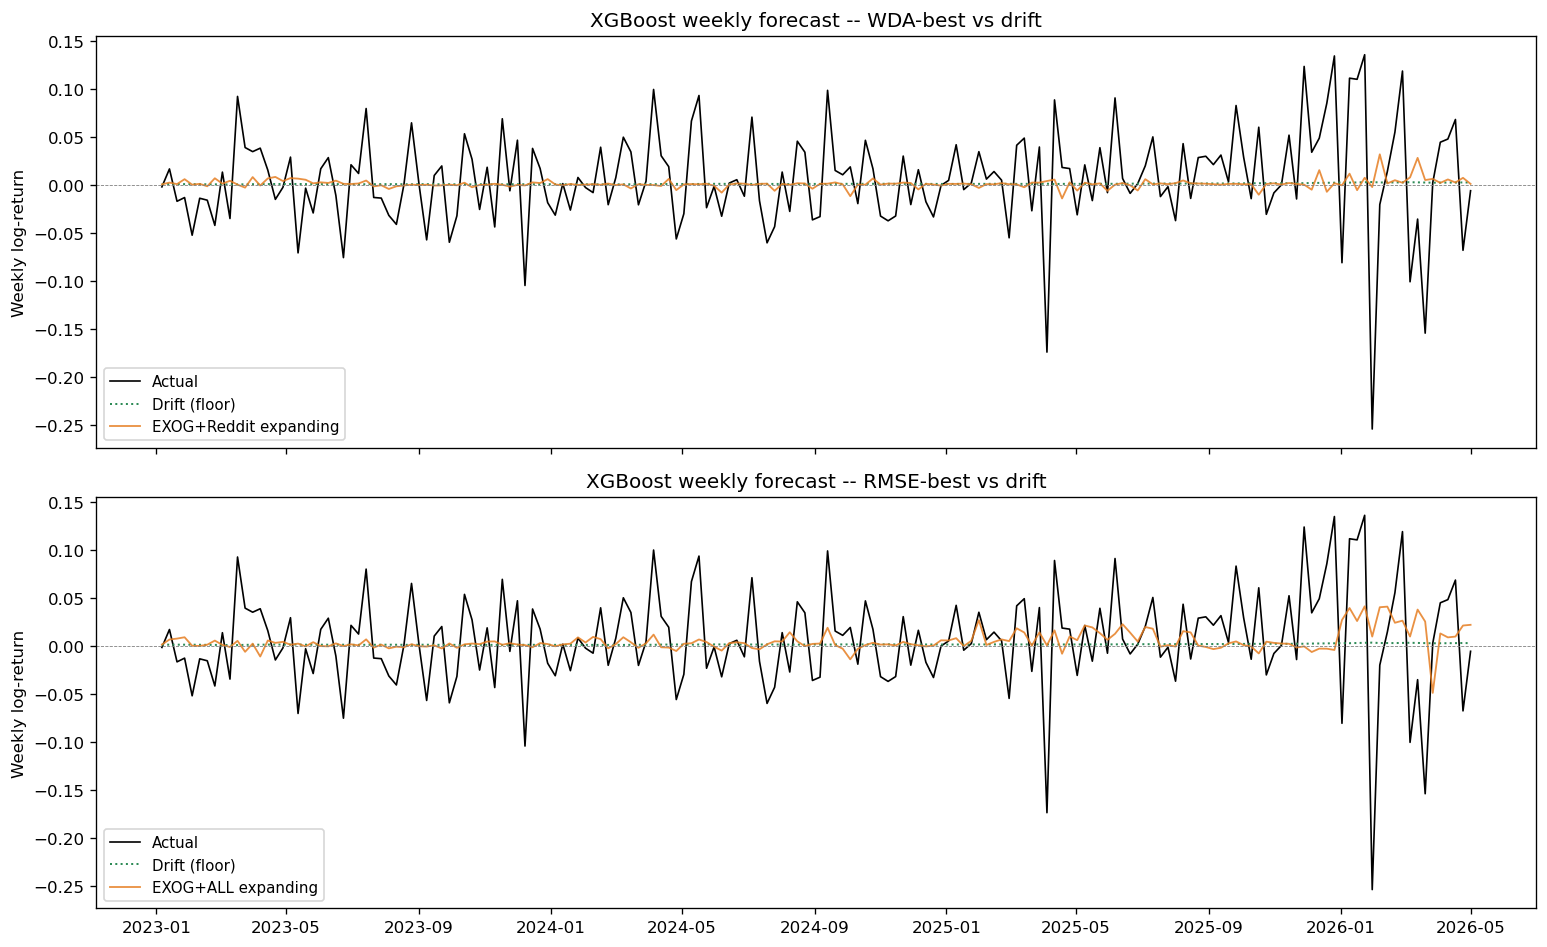

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
panels = [('WDA-best', best_name, best_pred), ('RMSE-best', best_name_rmse, best_pred_rmse)]
for ax, (tag, vname, vpred) in zip(axes, panels):
    ax.plot(test_index, y_test,     label='Actual',        lw=1,   color='black')
    ax.plot(test_index, drift_pred, label='Drift (floor)', lw=1.2, ls=':', color='seagreen')
    ax.plot(test_index, vpred,      label=vname,           lw=1.1, alpha=0.85, color='#e67e22')
    ax.axhline(0, color='grey', lw=0.5, ls='--')
    ax.set_title(f'XGBoost weekly forecast -- {tag} vs drift')
    ax.set_ylabel('Weekly log-return')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 9. Significance tests

The descriptive metrics in §5 rank the models; this section asks whether the differences are
**statistically real**. All tests are vs the **Drift** floor (prevailing mean = random walk).
Trees bundle own-history + public info, so this is a **semi-strong** test (weak form proper is
isolated in ARIMA). Effect size (OOS R²) is already in the §5 table; DM below supplies its
significance. Full definitions and Newey–West detail: `01_arima` §8 and [`tests.md`](tests.md).

| Test | Asks | Axis | Role |
|---|---|---|---|
| **DM — squared error** | Does *any* variant beat the random walk? | magnitude | **load-bearing** |
| **DM — absolute error** | …and does that survive heavy tails? | magnitude | robustness |
| **Pesaran–Timmermann** (§9b) | Do the *sign* calls beat chance? | direction | secondary |

**Sign convention:** `pred1` = Drift always. $d_t = \text{loss}(\text{Drift}) - \text{loss}(\text{model})$,
so **positive** DM = model beats Drift (evidence against efficiency); **negative** = Drift wins.

### DM — squared-error floor (load-bearing)

The headline efficiency test: does any variant produce significantly lower **squared** forecast
errors than the Drift? This is the proper significance test for the OOS R² in §5 — both are
MSFE-based, so DM is internally consistent with the effect size already shown.

In [36]:
# Semi-strong floor [PRIMARY] — squared-error loss vs Drift.
# DM is the significance test for the OOS R^2 in §5 (both MSFE-based).
print("Diebold-Mariano -- vs Drift floor   [squared error]")
print("Semi-strong test: can any variant beat the no-predictability drift?")
print("-" * 90)
for name, pred in all_candidates.items():
    diebold_mariano(y_test, drift_pred, pred, "Drift", name)

Diebold-Mariano -- vs Drift floor   [squared error]
Semi-strong test: can any variant beat the no-predictability drift?
------------------------------------------------------------------------------------------
Drift                                    vs EXOG expanding                            DM=-0.193  p=0.847  (ns)  -> winner: tie
Drift                                    vs EXOG rolling (100w)                       DM=-1.860  p=0.063  (ns)  -> winner: tie
Drift                                    vs Tech expanding                            DM=-0.154  p=0.878  (ns)  -> winner: tie
Drift                                    vs Tech rolling (100w)                       DM=-0.636  p=0.525  (ns)  -> winner: tie
Drift                                    vs EXOG+GS expanding                         DM=+0.107  p=0.915  (ns)  -> winner: tie
Drift                                    vs EXOG+GS rolling (100w)                    DM=-0.765  p=0.444  (ns)  -> winner: tie
Drift                      

### DM — absolute-error (robustness)

Same framework, loss $\lvert y-\hat y\rvert$ instead of $(y-\hat y)^2$. Weekly silver returns
are heavy-tailed — a few outlier weeks (squeeze, COVID, 2025 bull leg) dominate squared loss.
Absolute-error checks whether the result survives a less outlier-sensitive criterion. Squared
error stays the headline.

In [37]:
# Robustness -- floor test under ABSOLUTE-error loss.
print("Diebold-Mariano -- vs Drift floor   [absolute-error loss, robustness]")
print("-" * 90)
for name, pred in all_candidates.items():
    diebold_mariano(y_test, drift_pred, pred, "Drift", name, loss='ae')

Diebold-Mariano -- vs Drift floor   [absolute-error loss, robustness]
------------------------------------------------------------------------------------------
Drift                                    vs EXOG expanding                            DM=-1.003  p=0.316  (ns)  -> winner: tie
Drift                                    vs EXOG rolling (100w)                       DM=-1.603  p=0.109  (ns)  -> winner: tie
Drift                                    vs Tech expanding                            DM=-0.256  p=0.798  (ns)  -> winner: tie
Drift                                    vs Tech rolling (100w)                       DM=-0.262  p=0.794  (ns)  -> winner: tie
Drift                                    vs EXOG+GS expanding                         DM=+0.736  p=0.462  (ns)  -> winner: tie
Drift                                    vs EXOG+GS rolling (100w)                    DM=-0.032  p=0.974  (ns)  -> winner: tie
Drift                                    vs EXOG+NonLin expanding            

## 9b. Directional test — Pesaran–Timmermann (secondary lens)

DM is a *magnitude* test; DA/WDA are *directional*, so their significance needs **Pesaran–
Timmermann (1992)** — H0: predicted & actual signs independent (base-rate aware; *degenerate*
for a constant-sign forecast like the drift). **Secondary** to the DM-vs-Drift magnitude
verdict. Run across all variants to size the selection / multiple-testing picture.

In [38]:
from eval_utils import pesaran_timmermann

print("Pesaran-Timmermann directional test — full test window")
print("H0: predicted & actual signs independent  |  * p<0.05  ** p<0.01  *** p<0.001")
print("-" * 90)
pesaran_timmermann(y_test, drift_pred, name="Drift (always-up)")   # degenerate ref
pt_results = {n: pesaran_timmermann(y_test, p, name=n) for n, p in all_candidates.items()}
_tested = [r for r in pt_results.values() if not np.isnan(r['p'])]
_sig    = {n: r for n, r in pt_results.items() if not np.isnan(r['p']) and r['p'] < 0.05}
print(f"\n{len(_sig)}/{len(_tested)} variants significant at p<0.05 "
      f"(~{0.05 * len(_tested):.1f} expected by chance): {list(_sig)}")

print(f"\nPer-period PT — {best_name}:")
_yt = pd.Series(y_test, index=test_index)
_bp = pd.Series(best_pred, index=test_index)
for _lbl, (_a, _b) in PERIODS.items():
    _yy = _yt.loc[_a:_b].values
    _pp = _bp.loc[_a:_b].values
    if len(_yy) >= 12:
        pesaran_timmermann(_yy, _pp, name=f"  {_lbl}  (n={len(_yy)})")

Pesaran-Timmermann directional test — full test window
H0: predicted & actual signs independent  |  * p<0.05  ** p<0.01  *** p<0.001
------------------------------------------------------------------------------------------
Drift (always-up)                         DA=0.557  DA|indep=0.557  PT degenerate (constant-sign forecast)  -> winner: n/a
EXOG expanding                            DA=0.529  DA|indep=0.542  PT=-0.532  p=0.594  (ns)  -> winner: tie (chance)
EXOG rolling (100w)                       DA=0.506  DA|indep=0.517  PT=-0.319  p=0.750  (ns)  -> winner: tie (chance)
Tech expanding                            DA=0.529  DA|indep=0.537  PT=-0.287  p=0.774  (ns)  -> winner: tie (chance)
Tech rolling (100w)                       DA=0.540  DA|indep=0.499  PT=+1.107  p=0.268  (ns)  -> winner: tie (chance)
EXOG+GS expanding                         DA=0.540  DA|indep=0.542  PT=-0.081  p=0.936  (ns)  -> winner: tie (chance)
EXOG+GS rolling (100w)                    DA=0.546  DA|indep=0.

## 9c. Robustness — drop the 2025 bull run (full battery)

2025 carries the entire always-up line, so once the full-window tests are done, re-run **the whole
battery** — metrics + OOS R² + DM floor (se/ae) + PT — on **2023 + 2024 + 2026** only. Evaluation-only
(models unchanged, still trained walk-forward through 2025); pooled (per-year DM is underpowered). The
efficiency conclusion *strengthens* once the bull is removed.

In [39]:
from eval_utils import pesaran_timmermann
# Full battery on the non-bull window. Evaluation-only (forecasts unchanged); pooled for DM power.
mask_ex25 = np.asarray(test_index.year != 2025)
a_ex      = y_test[mask_ex25]
drift_ex  = drift_pred[mask_ex25]
au_ex     = np.sum(np.abs(a_ex) * (a_ex > 0)) / np.sum(np.abs(a_ex))
print(f'Ex-2025 sample: {int(mask_ex25.sum())} weeks  |  always-up WDA = {au_ex:.3f}')

print('\nMetrics (2025 excluded) -- RMSE / MAE / DA / WDA:')
evaluate('Drift (prevailing mean)', a_ex, drift_ex)
for name, pred in all_candidates.items():
    evaluate(name, a_ex, np.asarray(pred)[mask_ex25])

print('\nOOS R^2 vs Drift (2025 excluded) -- >0 beats the random walk:')
print('-' * 90)
for name, pred in all_candidates.items():
    _r2 = oos_r2(a_ex, np.asarray(pred)[mask_ex25], drift_ex) * 100
    print(f'  {name:40s} R2_OS = {_r2:+6.2f}%   -> winner: {name if _r2 > 0 else "Drift"}')

print('\nDM -- vs Drift floor, 2025 excluded [squared error]:')
print('-' * 90)
for name, pred in all_candidates.items():
    diebold_mariano(a_ex, drift_ex, np.asarray(pred)[mask_ex25], 'Drift', name)

print('\nDM -- vs Drift floor, 2025 excluded [absolute-error loss, robustness]:')
print('-' * 90)
for name, pred in all_candidates.items():
    diebold_mariano(a_ex, drift_ex, np.asarray(pred)[mask_ex25], 'Drift', name, loss='ae')

print('\nPesaran-Timmermann (2025 excluded) -- directional sign test:')
print('-' * 90)
for name, pred in all_candidates.items():
    pesaran_timmermann(a_ex, np.asarray(pred)[mask_ex25], name=name)

Ex-2025 sample: 122 weeks  |  always-up WDA = 0.520

Metrics (2025 excluded) -- RMSE / MAE / DA / WDA:
Drift (prevailing mean)                        RMSE=0.05275  MAE=0.03796  DA=0.500  WDA=0.520
EXOG expanding                                 RMSE=0.05270  MAE=0.03825  DA=0.492  WDA=0.555
EXOG rolling (100w)                            RMSE=0.05411  MAE=0.03896  DA=0.484  WDA=0.476
Tech expanding                                 RMSE=0.05251  MAE=0.03799  DA=0.508  WDA=0.571
Tech rolling (100w)                            RMSE=0.05431  MAE=0.03831  DA=0.557  WDA=0.517
EXOG+GS expanding                              RMSE=0.05286  MAE=0.03804  DA=0.516  WDA=0.520
EXOG+GS rolling (100w)                         RMSE=0.05423  MAE=0.03851  DA=0.508  WDA=0.503
EXOG+NonLin expanding                          RMSE=0.05232  MAE=0.03836  DA=0.500  WDA=0.567
EXOG+NonLin rolling (100w)                     RMSE=0.05474  MAE=0.03929  DA=0.475  WDA=0.478
EXOG+Tech expanding                            RMSE

## 10. 2026 zoom — actual vs best variants

Two panels (WDA-best | RMSE-best) on the 2026 YTD slice, drift overlaid. The RMSE-best hugs the
drift (minimising squared error ≈ reproducing the random walk); the WDA-best is the directional bettor.

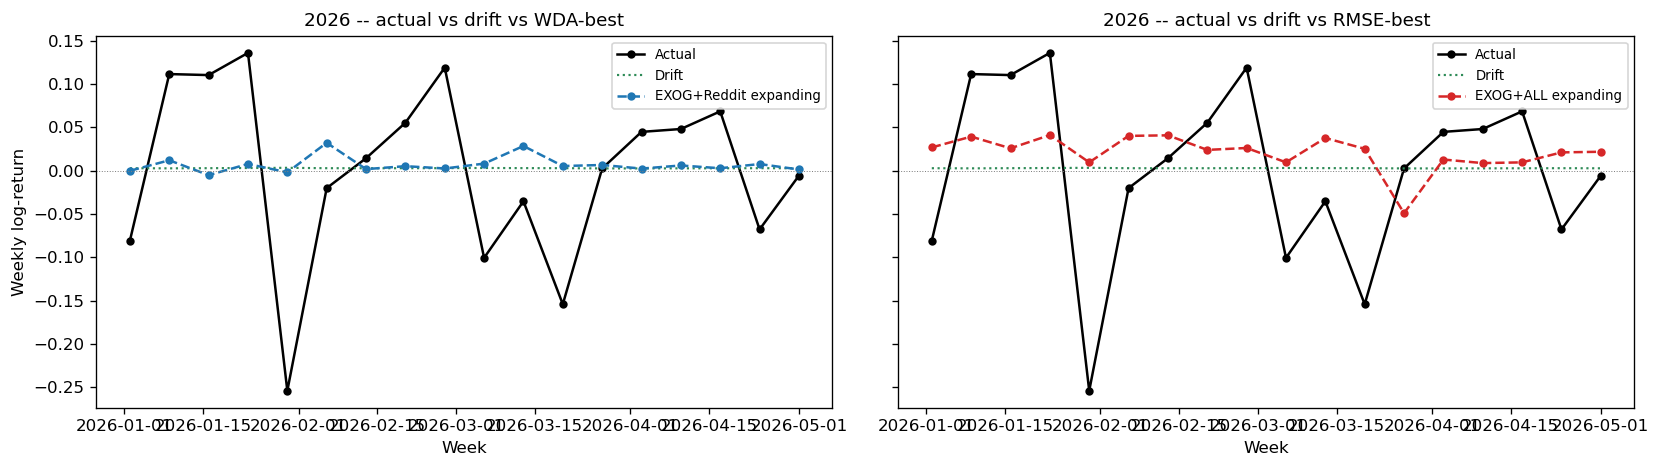

In [40]:
df26 = pd.DataFrame({'actual': y_test, 'drift': drift_pred,
                     'wda_best': best_pred, 'rmse_best': best_pred_rmse},
                    index=test_index).loc['2026':]

if df26.empty:
    print('No 2026 data in test set yet.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)
    panels = [('wda_best', best_name, '#1f77b4', 'WDA-best'),
              ('rmse_best', best_name_rmse, '#d62728', 'RMSE-best')]
    for ax, (col, vname, color, tag) in zip(axes, panels):
        ax.plot(df26.index, df26['actual'], color='black',    lw=1.5, marker='o', ms=4, label='Actual')
        ax.plot(df26.index, df26['drift'],  color='seagreen', lw=1.3, ls=':',  label='Drift')
        ax.plot(df26.index, df26[col],      color=color,      lw=1.5, marker='o', ms=4, ls='--', label=vname)
        ax.axhline(0, color='grey', lw=0.6, ls=':')
        ax.set_title(f'2026 -- actual vs drift vs {tag}', fontsize=11)
        ax.set_xlabel('Week')
        ax.legend(fontsize=8)
    axes[0].set_ylabel('Weekly log-return')
    plt.tight_layout()
    plt.show()